In [30]:
import yaml
import pandas as pd
import numpy as np
from datetime import time
import statsmodels.api as sm
import datetime as dt

from statsmodels.base.model import Model
from tqdm import tqdm
from typing import Literal



#df = pd.read_csv('data/SPY_15min_2020-01_to_2022-01.csv')


def load_config(path: str):
    """
    Loads the configuration from a YAML file.

    :param path: Path to the YAML configuration file.
    :return: A dictionary containing the configuration.
    """
    with open(path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def load_df(type: Literal["news", "SPY"], config: dict):
    """
    Loads the DataFrame for the specified year from the configuration.

    :param year: The year for which to load the DataFrame.
    :param config: The configuration dictionary containing file paths.
    :return: A pandas DataFrame containing the data for the specified year.
    """
    year = config["year"]
    if type == "news":
        df = pd.read_csv(config["news_path"])
    else:
        try: df = pd.read_csv(config[year])
        except KeyError:
            raise ValueError(f"No file path configured for {year}.")
    return df

def to_ger_timestamp(string: str):
    """
    Converts a string in the format 'YYYY-MM-DD HH:MM:SS' to a timezone-aware timestamp in Europe/Berlin.

    :param string: A string representing a date and time in the format 'YYYY-MM-DD (optional: HH:MM:SS').
    :return: A pandas Timestamp object localized to Europe/Berlin timezone.
    """
    dt_obj = pd.to_datetime(string)
    return dt_obj.tz_localize("Europe/Berlin")

def prepare_spy_data(data: pd.DataFrame, filter_dates: dict):
    """
    Prepares the SPY data by converting the datetime column to a timezone-aware index,
    setting the frequency to 15 minutes, and filtering for the specified time range.

    Please note that in spite of the labeling, "eventstart_CET" is actually Europe7/Berlin as it changes between CET (UTC+1) and CEST (UTC+2).

    :param data: A pandas DataFrame containing the SPY data with a datetime column.
    :param filter_dates: A dictionary with 'start_date' and 'end_date' keys for filtering the data.
    :return: A pandas DataFrame with the prepared SPY data.
    """
    # 1. Timezone specific preparation
    data['datetime'] = pd.to_datetime(data['Unnamed: 0'])
    data['datetime'] = data['datetime'].dt.tz_localize('America/New_York')  # Localize to ET timezone
    data.set_index('datetime', inplace=True)
    data.index = pd.DatetimeIndex(data.index)  # Ensure time-aware index
    data = data.asfreq('15min')  # Ensure the index is at 15-minute frequency
    data.index = data.index.tz_convert("Europe/Berlin") # Ensures correct timezone
    data = data.between_time("15:30", "22:00")
    data = data[data.index.weekday < 5]  # Keep only Monday (0) through Friday (4)

    # 2. Other preparations
    data.drop(columns=['Unnamed: 0'], inplace=True)  # Drop the original datetime column to avoid interpolation issues
    data.interpolate(method='time', inplace=True)
    data["y^2"] = (data["close"].apply(lambda x: np.log(x)).diff()) ** 2
    data = data.loc[filter_dates["start_date"]:filter_dates["end_date"]]

     # 3. Dummies
    data["day_of_week"] = data.index.dayofweek
    data["hour_of_day"] = data.index.hour
    day_dummies = pd.get_dummies(data["day_of_week"], prefix="FE_day", drop_first=True)
    hour_dummies = pd.get_dummies(data["hour_of_day"], prefix="FE_hour", drop_first=True)
    data = pd.merge(data, day_dummies, left_index=True, right_index=True)
    data = pd.merge(data,  hour_dummies, left_index=True, right_index=True)

    return data.drop(columns=["open", "high", "low", "volume", "close", "day_of_week", "hour_of_day"])

config = load_config("config.yaml")
filter_dates = {"start_date": to_ger_timestamp(config["start_date"]), "end_date": to_ger_timestamp(config["end_date"])}
filter_dates.values()
df = prepare_spy_data(load_df("SPY", config), filter_dates)
df


,y^2,FE_day_1,FE_day_2,FE_day_3,FE_day_4,FE_hour_16,FE_hour_17,FE_hour_18,FE_hour_19,FE_hour_20,FE_hour_21,FE_hour_22
datetime,,,,,,,,,,,,
2020-01-03 15:30:00+01:00,4.245277e-05,False,False,False,True,False,False,False,False,False,False,False
2020-01-03 15:45:00+01:00,1.896942e-07,False,False,False,True,False,False,False,False,False,False,False
2020-01-03 16:00:00+01:00,3.487367e-08,False,False,False,True,True,False,False,False,False,False,False
2020-01-03 16:15:00+01:00,2.421707e-08,False,False,False,True,True,False,False,False,False,False,False
2020-01-03 16:30:00+01:00,1.399066e-06,False,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 21:00:00+02:00,2.004112e-06,False,False,False,True,False,False,False,False,False,True,False
2020-08-28 21:15:00+02:00,7.707881e-07,False,False,False,True,False,False,False,False,False,True,False
2020-08-28 21:30:00+02:00,5.239030e-08,False,False,False,True,False,False,False,False,False,True,False


In [31]:
def safe_add(column: pd.Series, value: int): # Expects a datetimeIndex
    """
    Safely adds or subtracts a value in minutes to/from a datetime index, ensuring that the result remains within market open hours.
    This function is based on the internet appendix of the provided paper, thus, more information can be found there.

    :param column: A pandas Series with a DatetimeIndex, expected to be timezone-aware.
    :param value: An integer representing the number of minutes to add (positive) or subtract (negative).
    :return: A pandas Series with the same index, adjusted by the specified value in minutes.
    """
    # Confirm that the column has dates
    if not pd.api.types.is_datetime64_any_dtype(column):
        raise TypeError("Excpected a DateTime Series.")
    # Check if the index is timezone-aware
    if column.dt.tz is None:
        raise ValueError("DatetimeIndex must be timezone-aware.")
    # Cast to ET timezone for timezone aware consistency
    column = column.dt.tz_convert("America/New_York")
    # Check whether value is outside of market open hours
    hypothetical_values = column + pd.Timedelta(minutes=value)

    mask_before_open = (hypothetical_values.dt.time < dt.time(9,30))
    mask_during_open = (dt.time(9,30) <= hypothetical_values.dt.time) & (hypothetical_values.dt.time <= dt.time(16,0))
    mask_after_open = (hypothetical_values.dt.time > dt.time(16,0))

    date_of_action = column.dt.normalize() # Extract date and set hours to 0:00
    output = column.copy()
    output[mask_during_open] = output[mask_during_open] + pd.Timedelta(minutes=value)
    if value >= 0: # Safe add
        output[mask_before_open] = date_of_action[mask_before_open] + pd.Timedelta(hours=9, minutes=30) + pd.Timedelta(minutes=value)
        output[mask_after_open] = date_of_action[mask_after_open] + pd.Timedelta(days=1) + pd.Timedelta(hours=9, minutes=30) + pd.Timedelta(minutes=value)
    else: # Safe subtract
        # Window starts when trading closes
        output[mask_before_open] = date_of_action[mask_before_open] - pd.Timedelta(days=1) + pd.Timedelta(hours=16)
        output[mask_after_open] = date_of_action[mask_after_open] + pd.Timedelta(hours=16)

    return output # Caution: returns series with ET timezone




In [32]:
def prepare_news_df(data: pd.DataFrame):
    """
    Prepares the news DataFrame by converting the event start and end times to timezone-aware timestamps, filters the data based on the specified date range, and creates time windows for each event.

    :param data: A pandas DataFrame containing news events with 'eventstart_CET' and 'eventend_CET' columns.
    :return: A pandas DataFrame with the prepared news data, including 'window_start' and 'window_end' columns.
    """
    # Ensure correct timezone
    data["eventstart_CET"] = pd.to_datetime(data["eventstart_CET"], format="%d.%m.%Y %H:%M:%S").dt.tz_localize("Europe/Berlin", ambiguous=False)


    data["eventend_CET"] = pd.to_datetime(data["eventend_CET"], format="%d.%m.%Y %H:%M:%S").dt.tz_localize("Europe/Berlin")
    # Filter on timestamps of stock data
    data = data[(data["eventstart_CET"] >= filter_dates["start_date"]) & (data["eventstart_CET"] <= filter_dates["end_date"])]

    #data["eventstart_CET"] = data["eventstart_CET"].dt.floor("15min")  # Optional: Round down to the nearest 15 minutes (not mentioned in paper)

    # Correct time window creation according to paper:
    event_end_mask = data["eventend_CET"].notna()
    ad_hoc_mask = data["type"] == "Ad Hoc"

    # Only assign to rows where event_end_mask is False
    data.loc[~event_end_mask, "window_start"] = (
        safe_add(data.loc[~event_end_mask, "eventstart_CET"], -15)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[~event_end_mask, "window_end"] = (
        safe_add(data.loc[~event_end_mask, "eventstart_CET"], 30)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[ad_hoc_mask, "window_end"] = (
        safe_add(data.loc[ad_hoc_mask, "eventstart_CET"], 60)
        .dt.tz_convert("Europe/Berlin")
    )

    # Only assign to rows where event_end_mask is True
    data.loc[event_end_mask, "window_start"] = (
        safe_add(data.loc[event_end_mask, "eventstart_CET"], -20)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[event_end_mask, "window_end"] = (
        safe_add(data.loc[event_end_mask, "eventend_CET"], 20)
        .dt.tz_convert("Europe/Berlin")
    )

    return data

df_news = prepare_news_df(load_df("news", config))

df_news

,eventstart,eventend,name,type,subtype,subsubtype,description,source,scheduled,eventstart_CET,eventend_CET,window_start,window_end
49275,02.01.2020 19:00:00,NaT,UK BRC Shop Price Index,Macro Release,UK,BRC Shop Price Index,NaN,Bloomberg,1,2020-01-03 01:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49276,03.01.2020 02:45:00,NaT,FR CPI and Wages,Macro Release,FR,CPI and Wages,NaN,Bloomberg,1,2020-01-03 08:45:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49277,03.01.2020 03:00:00,NaT,ES Unemployment Net,Macro Release,ES,Unemployment Net,NaN,Bloomberg,1,2020-01-03 09:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49278,03.01.2020 04:00:00,NaT,DE CPI Hesse,Macro Release,DE,CPI Hesse,NaN,Bloomberg,1,2020-01-03 10:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49279,03.01.2020 04:30:00,NaT,UK Monetary Aggregates,Macro Release,UK,Monetary Aggregates,NaN,Bloomberg,1,2020-01-03 10:30:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51552,28.08.2020 05:00:00,NaT,IT Auction Result Bond or Note,Auction,IT Result,Bond or Note,NaN,Bloomberg,1,2020-08-28 11:00:00+02:00,NaT,2020-08-27 22:00:00+02:00,2020-08-28 16:00:00+02:00
51553,28.08.2020 09:05:00,28.08.2020 09:43:00,BoE: Speech by Governor,Central Bank,BoE,Speech by Governor,"Bailey at Jackson Hole: ""it looks from today’s...",https://www.bankofengland.co.uk/-/media/boe/fi...,0,2020-08-28 15:05:00+02:00,2020-08-28 15:43:00+02:00,2020-08-27 22:00:00+02:00,2020-08-28 16:03:00+02:00
51554,28.08.2020 09:45:00,NaT,US Chicago Purchasing Manager,Macro Release,US,Chicago Purchasing Manager,NaN,Bloomberg,1,2020-08-28 15:45:00+02:00,NaT,2020-08-28 15:30:00+02:00,2020-08-28 16:15:00+02:00
51555,28.08.2020 10:00:00,NaT,US University of Michigan Surveys,Macro Release,US,University of Michigan Surveys,NaN,Bloomberg,1,2020-08-28 16:00:00+02:00,NaT,2020-08-28 15:45:00+02:00,2020-08-28 16:30:00+02:00


In [33]:
def create_news_dummies(spy_df: pd.DataFrame, news_df: pd.DataFrame, group_by: str = "type"):
    """
    Creates dummy variables for news events based on the specified grouping level.

    :param spy_df: A pandas DataFrame containing SPY data with a datetime index.
    :param news_df: A pandas DataFrame containing news events with 'window_start' and 'window_end' columns.
    :param group_by: The column name to group by (e.g., 'subsubtype', 'type').
    :return: A pandas DataFrame with dummy variables for each unique value in the specified grouping column.
    """

    print(f"creating {len(news_df[group_by].unique())} event dummie variables")
    dummies = {}
    for subtype, df_type in news_df.groupby(group_by):
        mask = pd.Series(False, index=df.index)
        for _, row in df_type.iterrows():
            mask = mask | ((spy_df.index > row["window_start"]) & (spy_df.index <= row["window_end"]))
        dummies[f"D_{subtype}"] = mask

    return pd.concat([spy_df, pd.DataFrame(dummies)], axis=1)

df_complete = create_news_dummies(df, df_news, group_by="name")
df_complete

creating 181 event dummie variables


,y^2,FE_day_1,FE_day_2,FE_day_3,FE_day_4,FE_hour_16,FE_hour_17,FE_hour_18,FE_hour_19,FE_hour_20,...,D_US ISM Releases,D_US Jobless Claims,D_US Leading Index,D_US New Home Sales,D_US Nonfarm Productivity & US Unit Labor Costs,D_US PPI,D_US Production and Capacity Utilization,D_US Retail Sales,D_US Trade Balance,D_US University of Michigan Surveys
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-03 15:30:00+01:00,4.245277e-05,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2020-01-03 15:45:00+01:00,1.896942e-07,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2020-01-03 16:00:00+01:00,3.487367e-08,False,False,False,True,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2020-01-03 16:15:00+01:00,2.421707e-08,False,False,False,True,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2020-01-03 16:30:00+01:00,1.399066e-06,False,False,False,True,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 21:00:00+02:00,2.004112e-06,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2020-08-28 21:15:00+02:00,7.707881e-07,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2020-08-28 21:30:00+02:00,5.239030e-08,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
# Regression
def run_regression(df: pd.DataFrame, window_amt: int = 4):
    """
    Runs an OLS regression on the provided DataFrame. Automatically handles the rolling variance calculation based on the specified window amount. Also extracts dummies and fixed effects from the DataFrame. Dummies need to start with "D_" and fixed effects with "FE_".

    :param df: A pandas DataFrame containing the data for regression.
    :param window_amt: The number of 15-minute intervals to use for the rolling variance calculation.
    :return: A fitted OLS model.
    """

    fixed_effects = df.filter(regex="^FE_").astype(float)
    lagged_variance = df['y^2'].rolling(window=window_amt).sum()  # assuming window_amt 15-min intervals according to paper
    event_dummies = df.filter(regex="^D_").astype(float)


    #x = pd.concat([event_dummies, fixed_effects, lagged_variance], axis=1)
    x = pd.concat([event_dummies, fixed_effects, lagged_variance], axis=1).iloc[window_amt-1:]

    #x = event_dummies.iloc[window_amt-1:]
    x = sm.add_constant(x)
    y = df["y^2"].iloc[window_amt-1:].astype(float)

    return sm.OLS(y, x).fit()

model = run_regression(df_complete, window_amt=4)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    y^2   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     16.02
Date:                Sat, 12 Jul 2025   Prob (F-statistic):               0.00
Time:                        13:50:46   Log-Likelihood:                 36022.
No. Observations:                4614   AIC:                        -7.167e+04
Df Residuals:                    4428   BIC:                        -7.047e+04
Df Model:                         185                                         
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
const                                                     6.717e-05   1.07e-05      6.293      0.000    4.62e-05    8.81e-05
D_AT Wholesale Price Index                                   0.0002   9.64e-05      1.558      0.119   -3.88e-05       0.000
D_Ad Hoc: Covid-19                                        6.088e-05   1.16e-05      5.261      0.000    3.82e-05    8.36e-05
D_Ad Hoc: OPEC                                           -2.411e-05   3.22e-05     -0.748      0.454   -8.73e-05    3.91e-05
D_Ad Hoc: Other Unscheduled Event                        -3.227e-06   6.16e-05     -0.052      0.958      -0.000       0.000
D_Ad Hoc: Sovereign Credit Ratings                        2.525e-05   4.75e-05      0.532      0.595   -6.78e-05       0.000
D_Ad Hoc: Trump                                          -6.009e-06   2.19e-05     -0.274      0.784    -4.9e-05    3.69e-05
D_BE Budget Balance                                      -1.129e-05   2.76e-05     -0.410      0.682   -6.53e-05    4.28e-05
D_BE Unemployment Rate                                   -3.826e-05   5.42e-05     -0.705      0.481      -0.000    6.81e-05
D_BoC: Press Release                                     -1.351e-05   3.04e-05     -0.444      0.657   -7.31e-05    4.61e-05
D_BoE: Minutes                                            6.311e-05      0.000      0.398      0.691      -0.000       0.000
D_BoE: Press Conference                                   9.167e-06   6.03e-05      0.152      0.879      -0.000       0.000
D_BoE: Press Release                                     -2.598e-05   3.74e-05     -0.695      0.487   -9.93e-05    4.73e-05
D_BoE: Speech by Governor                                   -0.0001      0.000     -1.116      0.265      -0.000       0.000
D_BoJ: Minutes                                               0.0001   4.25e-05      2.434      0.015    2.01e-05       0.000
D_BoJ: Monthly Report                                        0.0002   9.33e-05      1.739      0.082   -2.07e-05       0.000
D_BoJ: Press Conference                                   3.163e-05   6.59e-05      0.480      0.631   -9.75e-05       0.000
D_BoJ: Press Release                                     -2.243e-05   6.83e-05     -0.329      0.743      -0.000       0.000
D_BoJ: Summary of Opinions                                  -0.0001   6.76e-05     -1.995      0.046      -0.000   -2.31e-06
D_CH CPI                                                 -8.254e-05      6e-05     -1.376      0.169      -0.000    3.51e-05
D_CH Producer, Import Prices                             -1.357e-05   7.16e-05     -0.189      0.850      -0.000       0.000
D_CH Retail Sales                                           -0.0003   7.48e-05     

In [40]:
# Compute Omega_k
def compute_omega_k(model, df: pd.DataFrame, k: int):
    """
    Computes the Omega_k value based on the fitted OLS model and the DataFrame.

    :param model: A fitted OLS model from statsmodels.
    :param df: A pandas DataFrame containing the data with a column "y^2" representing the squared returns.
    :param k: Number of top k columns based on t-statistics.
    :return: The computed Omega_k value and the top k columns based on t-statistics.
    """
    event_columns = df.filter(regex="^D_").columns  # Select only event dummies
    tstats = model.tvalues[event_columns].abs()  # Absolute t-statistics
    top_k_columns = tstats.nlargest(k).index  # Select top k columns based on t-statistics
    betas = model.params[top_k_columns]

    # Formula from paper
    p_d_eq_1 = df[top_k_columns].mean()
    product = betas * p_d_eq_1
    mu_ysqr = np.mean(df["y^2"].dropna())  # Mean of y^2, excluding the first rows due to rolling window
    omega_k = sum(product) / mu_ysqr

    return omega_k, top_k_columns
k = 10 # Number of top news types to consider
omega, top_k_columns = compute_omega_k(model, df_complete, k)
omega

np.float64(0.5155458312079432)

In [36]:
#omega chatgpt version #TODO DAS LÖSCHEN WEIL HIER KOMMEN VIEL ZU GROßE WERTE RAUS HILFE
def compute_omega_i(df: pd.DataFrame, top_k_columns):
    """
    Computes the impact on the variance for a given dummy variable in a DataFrame.

    :param: df: A pandas DataFrame containing the data with a column "y^2" representing the squared returns.
    :param: dummy: A string representing the name of the dummy variable column.
    :return: The computed Omega_i value.
    """
    ek_y2_given_D1 = [df.loc[df[dummy] == 1, "y^2"].dropna().mean() for dummy in top_k_columns] # Accounting for first rows due to rolling window
    P_d1 = [(df[dummy] == 1).mean() for dummy in top_k_columns]
    E_y2 = df["y^2"].dropna().mean()

    product = 0
    for i in range(len(ek_y2_given_D1)):
        product += P_d1[i] * ek_y2_given_D1[i]
        print(f"Dummy: {top_k_columns[i]}, P(D=1): {P_d1[i]}, E(y^2 | D=1): {ek_y2_given_D1[i]}")

    return product / E_y2
print(compute_omega_i(df_complete, top_k_columns))



Dummy: D_FR Auction Result Bill, P(D=1): 0.02295863114576565, E(y^2 | D=1): 0.00015009558744316642
Dummy: D_ECB: Asset Purchase Programmes, P(D=1): 0.009096816114359974, E(y^2 | D=1): 2.3933529711010637e-06
Dummy: D_DE Auction Result Bill, P(D=1): 0.016894087069525665, E(y^2 | D=1): 7.112757652139025e-05
Dummy: D_ECB: Weekly Financial Statement, P(D=1): 0.007364089235434265, E(y^2 | D=1): 0.0002060389037039786
Dummy: D_US Chicago Purchasing Manager, P(D=1): 0.005198180636777128, E(y^2 | D=1): 4.982434593230428e-06
Dummy: D_SNB: Press Conference, P(D=1): 0.00043318171973142733, E(y^2 | D=1): 3.655953752897418e-06
Dummy: D_Ad Hoc: Covid-19, P(D=1): 0.02360840372536279, E(y^2 | D=1): 0.00010117416690234568
Dummy: D_DE IFO Survey, P(D=1): 0.006281134936105696, E(y^2 | D=1): 8.02958469258393e-05
Dummy: D_CH Retail Sales, P(D=1): 0.005198180636777128, E(y^2 | D=1): 0.00013822749713821857
Dummy: D_JP Current Account, P(D=1): 0.005198180636777128, E(y^2 | D=1): 0.00018243174264702766
0.6234653

In [37]:
print((0.000065 * 0.034221 + 0.000032 * 0.142084 + 0.000010 * 0.235651 + 0.000004 * 0.148581) / 0.00001728070850 )



0.5625861347062245


In [38]:
#todo time series variance decomposition
#todo bar chart für Omega_k
#todo overnight dummies -> difference between innerhalb der Handelszeit & außerhalb der Handelszeit plotten !
#todo plots!



In [39]:
# Bootsrapping
def bootstrap(df: pd.DataFrame, n: int = 1000):
    """
    Generates bootstrap samples from the provided DataFrame.

    :param df: A pandas DataFrame to bootstrap from.
    :param n: Number of bootstrap samples to generate.
    :return: A generator yielding bootstrap samples.
    """

    for i in tqdm(range(n), desc="Bootstrapping"):
        sample = df.sample(frac=1, replace=True)
        yield sample

all_betas = []
all_tstats = []
all_omegas = []
for sampled_df in bootstrap(df_complete):
    model = run_regression(sampled_df, window_amt=4)
    omega_k, _ = compute_omega_k(model, sampled_df, 4)
    all_omegas.append(omega_k)
    all_betas.append(model.params[top_k_columns])
    all_tstats.append(model.tvalues[top_k_columns].abs())

#TODO überlegen, ob das das gleiche Ergebnis erzielt wie das sortieren der typen nach tstat nachdem die 1000 Regressionen durchgeführt wurden und anschließender Berechnung von omega_k


Bootstrapping:  10%|▉         | 96/1000 [00:30<04:45,  3.17it/s]


KeyboardInterrupt: 

In [129]:
df_betas = pd.concat(all_tstats, axis=1)
df_betas.T.mean()


D_Macro Release    3.826194
D_Ad Hoc           6.324490
D_Central Bank     1.292742
D_Auction          1.146589
dtype: float64

In [130]:
#TODO Comparing bootstrapped results to first regression results

In [131]:
df_tstats = pd.concat(all_betas, axis=1)
df_tstats.T.mean()


D_Macro Release   -0.000028
D_Ad Hoc           0.000055
D_Central Bank    -0.000004
D_Auction          0.000003
dtype: float64

In [132]:
np.mean(all_omegas)

np.float64(-0.11368846185170417)

In [133]:
def compute_omega_k(model, df: pd.DataFrame, k: int):
    """
    Computes the Omega_k value based on the fitted OLS model and the DataFrame.

    :param model: A fitted OLS model from statsmodels.
    :param df: A pandas DataFrame containing the data with a column "y^2" representing the squared returns.
    :param k: Number of top k columns based on t-statistics.
    :return: The computed Omega_k value and the top k columns based on t-statistics.
    """
    event_columns = df.filter(regex="^D_").columns  # Select only event dummies
    tstats = model.tvalues[event_columns].abs()  # Absolute t-statistics
    top_k_columns = tstats.nlargest(k).index  # Select top k columns based on t-statistics
    betas = model.params[top_k_columns]

    # Formula from paper
    p_d_eq_1 = df[top_k_columns].mean()
    product = betas * p_d_eq_1
    mu_ysqr = np.mean(df["y^2"].dropna())  # Mean of y^2, excluding the first rows due to rolling window
    omega_k = sum(product) / mu_ysqr

    return omega_k, top_k_columns

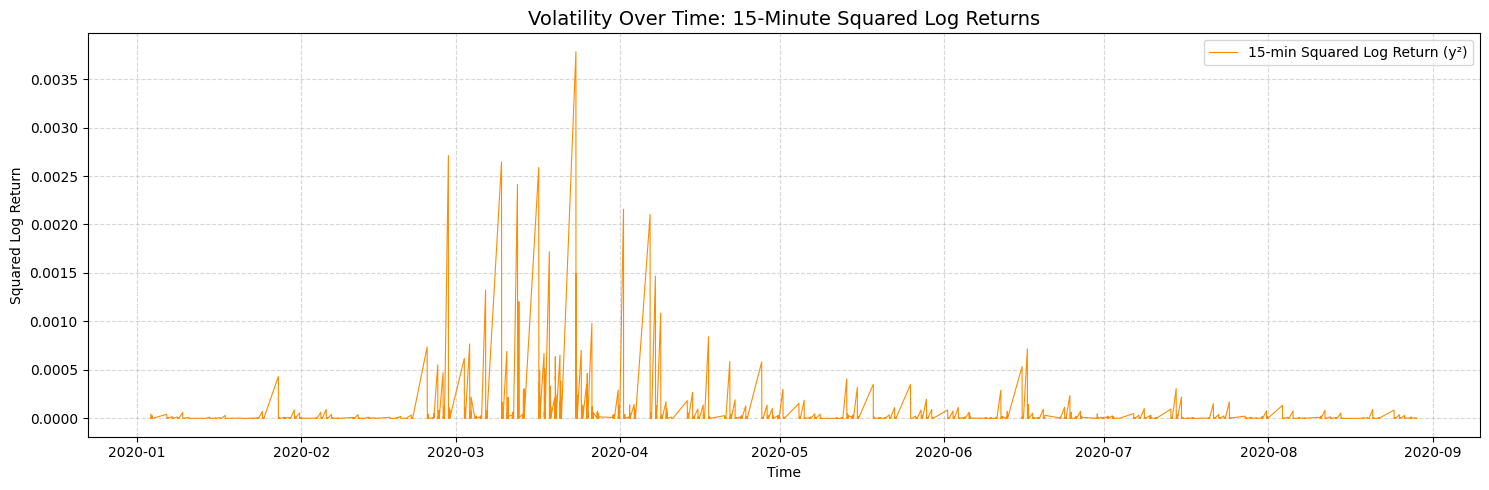

In [134]:
# TODO Plotting mit chatgpt letsgo
# Chart 1: Time Series of Squared Log Returns (y^2)
# TODO hier könnte man Pfeile auf die Events setzen, die signifikant sind? Aber dann müssten wir natürlich nach Event aufschlüsseln, nur eine Idee.

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df.index, df["y^2"], color='darkorange', label='15-min Squared Log Return (y²)', linewidth=0.8)
plt.title("Volatility Over Time: 15-Minute Squared Log Returns", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Squared Log Return")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


TypeError: no numeric data to plot

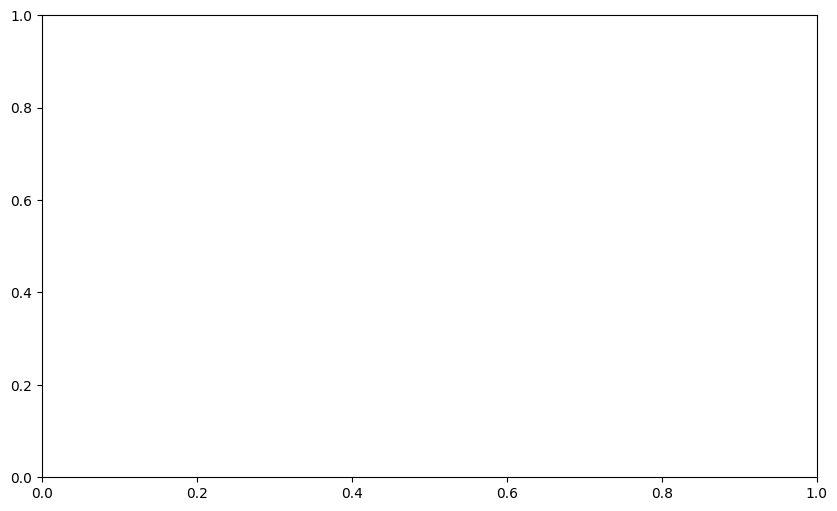

In [135]:
# Chart 2: Variance Explained (Omega_k) by News Type

import matplotlib.pyplot as plt

# Example decomposition values (replace with your real results)
omega_dict = {

}

omega_series = pd.Series(omega_dict).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
omega_series.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Variance Explained by News Type (Ωₖ)', fontsize=14)
plt.ylabel('Fraction of Total Variance')
plt.xlabel('News Type')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Ist irgendwas von gpt haha gefällt mir nicht, wäre cool wenn wir alles in einen Balken packen könnten
